Santiago andrés Acosta Díaz 

Astrofísica Computacional 

# Enfriamiento térmico de la corteza de una estrella de neutrones 

Se nos pide resolver la PDF simplificada 

$$
    \frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial z^2} - \epsilon_\nu T^5
$$

dadas las condiciones de frontera e iniciales. (En el pseudocódigo trabajamos con $T^8$, que es la forma usual en cómo se escribe esta ecuación)

* $T(0, t) = T_{surf} = 10^6 K$
* $T(L, t) = T_{core} = 10^9 K$
* $T(z, 0) = T_{core}$

con 

$$
\begin{gather}
L = 10^3 m \qquad \alpha = 10^{-2} \frac{m^2}{s} \qquad T_{core} = 10^9 K \\
T_{surf} = 10^6 K \qquad \epsilon_v = 10^{-53} \frac{1}{K^8 s} \qquad t_{max} = 10^6 s
\end{gather}
$$

usando el método de Crank-Nicolson.

**_Nota:_** _nos dan un pseudocódigo a implementar. Entonces, voy a hacerle case al pseudocódigo._

## Módulo 1

Definición de parámetros y malla

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.linalg import solve_banded

print("Preparando simulación")

# Definimos las constantes 
L = 1.e3 
alpha = 1.e-2
eps_nu = 1.e-53
T_core = 1.e9
T_surf = 1.e6
t_max = 1.e6

print("Constantes preparadas")

# Definimos parámetros numéricos
N = 100 
dx = L / (N - 1)
dt = 1000.0
lam = alpha * dt / (dx**2)
n_steps = int(t_max / dt)

# Verificar estabilidad 

print(f"Valor de lambda = {lam}")
if (lam) > 10.0:
    raise ValueError("Lambda muy grande | Reducir dt")

print("Parámetros numéricos preparados")

# Inicializar malla

x = np.linspace(0., L, N)
T = np.ones(N) * T_core
T[0] = T_surf
T[-1] = T_core

print("Malla inicializada")

Preparando simulación
Constantes preparadas
Valor de lambda = 0.09801000000000001
Parámetros numéricos preparados
Malla inicializada


## Módulo 2

Ensamblado de la matriz tridiagonal 

Aquí intenté inicialmente seguir el pseudocódigo, pero en realidad resulta mejor derivar las cosas desde el inicio.

El método CN se diferencia en, simplemente, tomar las derivadas parciales espaciales como el promedio de las respectivas derivadas en el tiempo, es decir, a diferencia del método implícito en donde usamos la diferencia finita centrada de segundo orden, en CN hacemos que 

$$
    \frac{\partial^2 T}{\partial z^2} \approx \frac{1}{2} \left[ \frac{T_{i-1}^{n+1} - 2 T_{i}^{n+1} + T_{i+1}^{n+1}}{\Delta z^2} + \frac{T_{i-1}^{n} - 2 T_{i}^{n} + T_{i+1}^{n}}{\Delta z^2} \right]
$$

mientras todo lo demás lo tratamos de la misma forma que el método implícito. Lo importante ahora es que, haciendo álgebra y definiendo $\lambda = \alpha \Delta t / \Delta z^2$, llegamos a que 

$$
    -\frac{\lambda}{2} T^{n+1}_{i-1} + (1+\lambda)T^{n+1}_{i} - \frac{\lambda}{2} T^{n+1}_{i+1} = \frac{\lambda}{2} T^{n}_{i-1} + (1-\lambda)T^{n}_{i} + \frac{\lambda}{2} T^{n}_{i+1} - \Delta t \epsilon_\nu T^n_i
$$

en todos los nodos menos en las fronteras. Lo interesante aquí es que el lado derecho lo conocemos perfectamente, pues son puntos ya calculados (tiempo $n$). Esta ecuación anterior la podemos escribir matricialmente como 

$$
\left(
\begin{matrix}
    1 & 0 & 0 & \cdots & 0 \\
    -\frac{\lambda}{2} & 1 + \lambda & - \frac{\lambda}{2} & \cdots & 0 \\
    0 & -\frac{\lambda}{2} & 1 + \lambda & - \frac{\lambda}{2} & \vdots \\
    \vdots & \ddots & \ddots & \ddots & 0 \\
    0 & \cdots & 0 & 0 & 1
\end{matrix}
\right)
\,
\left( 
\begin{matrix}
    T_0^{n+1} \\
    T_1^{n+1} \\
    T_2^{n+1} \\
    \vdots \\
    T_{N-1}^{n+1} \\
\end{matrix}
\right)
\,
=
\,
\left( 
\begin{matrix}
    T_{surf} \\
    RHS_1 \\
    RHS_2 \\
    \vdots \\
    T_{core} \\
\end{matrix}
\right)
$$

donde $RHS_i = \frac{\lambda}{2} T_{i-1}^n + (1 - \lambda) T_i^n + \frac{\lambda}{2} T_{i+1}^n - \Delta t \epsilon_\nu \left(T_i^n\right)^5$.

Aquí es importantísimo ver que la primera y última fila de la matriz corresponden a las condiciones de frontera que tenemos, las cuales se establecen con el primer y último elemento del vector a la derecha.

In [2]:
lam2 = lam/2.0 # Constante que se usa mucho

def construir_sistema(T, lam = lam, eps_nu = eps_nu, dt = dt, N = N):

    # La diagnoal principal siempre es 1+\lambda menos en las fronteras
    diag_pri = np.full(N, 1. + lam)
    diag_pri[[0, N-1]] = 1.

    # Las diagnoales superiores e inferiores son siempre \lambda/2 menos en índices conflictivos
    diag_sup = np.full(N, -lam2)
    diag_sup[0] = 0.

    diag_inf = np.full(N, -lam2)
    diag_inf[N-1] = 0.


    # VECTOR DEL LADO DERECHO
    # Inicializamos este vector y le ponemos nuestras condiciones de frontera
    b = np.zeros(N)
    b[0] = T_surf
    b[-1] = T_core

    # Creamos el interior del vector
    for i in range(1, N-1):
        # Q_nu_i = eps_nu * T[i]**8
        T_scale = 1.0e9                                   # Hacemos el paso previo de multiplicar epsilon * T para evitar overflows
        Q_nu_i = eps_nu * (T[i] / T_scale)**8 * T_scale   # Q_nu es el epsilon_nu * T^8
        
        b[i] = lam2 * (T[i-1] + T[i+1]) + (1. - lam) * T[i] - dt * Q_nu_i

    return diag_inf, diag_pri, diag_sup, b

## Módulo 3

Algoritmo de Thomas

Los anterior nos devuelve el sistema que devemos solucionar para solucionar cada paso de tiempo. Ahora, para solucionar el sistema, utilzamos el método de Thomas, que resuleve estos sistemas tridiagonales eficientemente. Su derivación se omite, este método es prácticamente copia y pega del pseudocódigo.

In [3]:
def Thomas(a, b, c, d, N = N):

    # Creamos las variables primadas
    c_prime = np.zeros_like(c)
    d_prime = np.zeros_like(d)

    c_prime[0] = c[0] / b[0]
    d_prime[0] = d[0] / b[0]

    for i in range(1, N):
        m = b[i] - a[i] * c_prime[i-1]

        c_prime[i] = c[i] / m
        d_prime[i] = (d[i] - a[i] * d_prime[i-1]) / m

    # Sustitución hacia atrás
    # Creamos el x 
    X = np.zeros(N)
    X[-1] = d_prime[-1]
    
    for i in range(N-2, -1, -1):
        X[i] = d_prime[i] - c_prime[i] * X[i+1]

    return X



# Módulo 4

Integración y diagnósticos

Guardando snapshot de t= 1000.0
Guardando snapshot de t= 10000.0
Guardando snapshot de t= 100000.0
Guardando snapshot de t= 1000000.0


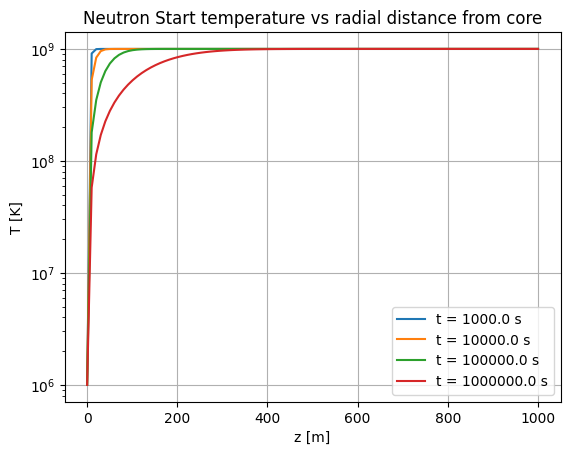

In [4]:
tiempos_salida = [1.e3, 1.e4, 1.e5, 1.e6]
T_history = []
F_history = []
t = 0.

for paso in range(1, n_steps + 1):
    a, b, c, rhs = construir_sistema(T.copy())
    
    T_interior = Thomas(a, b, c, rhs, N) # Para utilizar el Thomas que creamos

    # # Para utiizar un solver más común
    # ab = np.zeros((3, N))
    # ab[0, 1:] = c[:-1]   # upper diagonal — shift right, leave ab[0,0] = 0
    # ab[1, :]  = b        # main diagonal
    # ab[2, :-1] = a[1:]  # lower diagonal — shift left, leave ab[2,-1] = 0
    # T_interior = solve_banded((1, 1), ab, rhs)

    T = T_interior
    t = t + dt 

    # Diagnostico
    F_history.append((alpha * (T[1] - T[0]) / dx, t))

    if t in tiempos_salida:
        print("Guardando snapshot de t=",t)
        T_history.append((T.copy(), t))

for (T_snap, t_snap) in T_history:
    plt.plot(x, T_snap, label = f"t = {t_snap} s")

plt.legend()
plt.grid()
plt.title("Neutron Start temperature vs radial distance from core")
plt.xlabel("z [m]")
plt.ylabel("T [K]")
plt.yscale("log")
plt.show()

A partir de estas gráficas podemos ver cómo se comporta la temperatura en el sistema:

Las temperaturas altas iniciales (dadas por las condiciones iniciales) transicionan lentamente a temperaturas más bajas en las regiones más cercanas a la superficie fría, mientras que, para el core caliente, las temperaturas alrededor de él siempre se mentienen altas. Esto concuerda con lo que físicamente esperamos: la única fuente de energía es el núcleo, el cual condicionamos a que siempre esté caliente; la energía inicial en el interior de la estrella "se disipa" hacia la región fría, pero al final, siempre habrá un gradiente de temperatura entre el núcleo que inyecta calor al sistema y la superficie, que lo expulsa. 

__NOTA: un happy accident que tiene el código es que este no reinicia el array de temperaturas al ejecutar el módulo 4, entonces, si uno vuelve a correr esta celda, se puede ver cómo estas temperaturas al final convergen a un perfil único.__

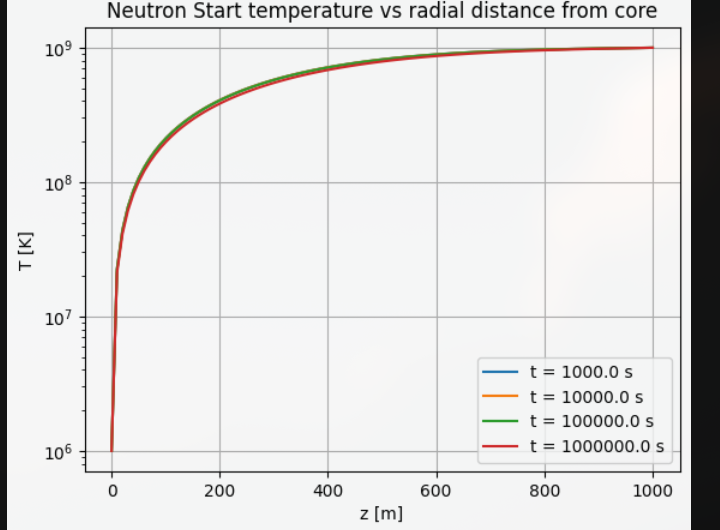

Ahora, revisamos el diagnóstico del flujo de calor

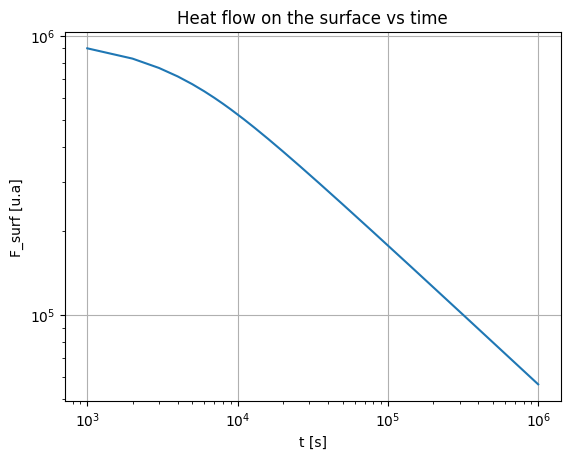

In [5]:
plt.loglog(np.array(F_history)[::,1], np.array(F_history)[::,0])
plt.grid()
plt.title("Heat flow on the surface vs time")
plt.xlabel("t [s]")
plt.ylabel("F_surf [u.a]")
plt.yscale("log")
plt.show()

El flujo de calor nos está casi diciendo qué tanta energía "escapa" a través de la superficie, suponiendo que esta es justo la necesaria para que la estrella mantenga su condición de frontera. Este flujo decrese con el tiempo, lo que es esperado, pues a medida que la estrella pierde su energía inicial, el gradiente de temperatura decrese y con ello el movimiento de energía es menor. Para $t$s grandes (alrededor de $t > 10^4s$), el sistema parece llegar a alguna suerte de equilibrio, pero lo interesante aquí es aprovechar el _happy accident_ comentado anteriormente y ver el comporamiento de este flujo para valores de $t$ aún más grandes.

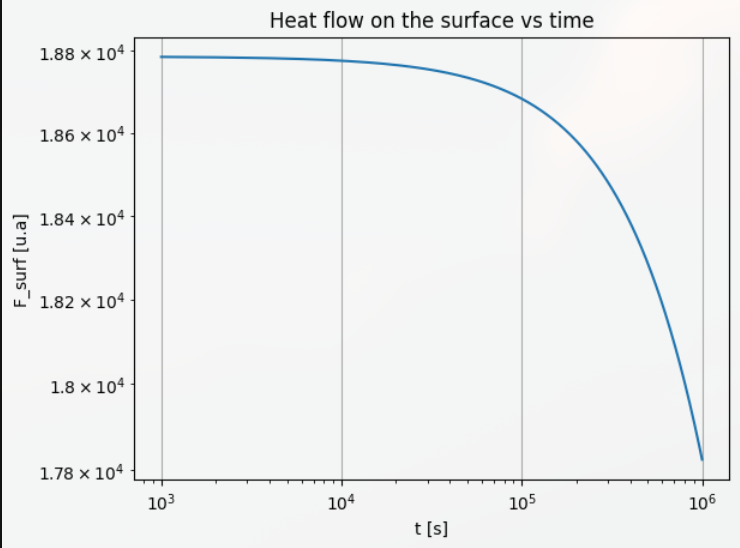

Cuando $t >> 10^6$ (en las imágenes los ejes temporales no están bien puestos), se ve claramente que este flujo parece tender a $F_{max} \approx 1.78 \times 10^4$ [u.a.]. Esto nos indica que, para tiempos muy grandes, hay un estado de equilibrio entre la energía que crea el núcleo y la que expulsa la superficie en este valor de flujo, la cual sería, en caso tal de que observemos esta estrella, el valor del flujo de energía que mediríamos (considerando que la vida de la estrella es mucho mayor a este tiempo simulado).

## Comparación con el método implícito y el explícito

Empezamos creando las funciones para ambos métodos.

### Método explícito

Tratamos todo con diferencias finitas usuales de toda la vida. El sistema a resolver sería entonces

$$
    T^{n+1}_i = T^n_i + \lambda \left( T^n_{i-1} - 2T^n_i + T^n_{i+1} \right) - \Delta t \epsilon_\nu \left( T_i^n \right)^8
$$

Y no necesitamos resolver ningún sistema matricial.


### Método implícito
Aquí, lo que cambia es que, para la segunda derivada espacial, consideramos su valor en el siguiente paso de tiempo, es decir, vamos a tratar

$$
    \frac{\partial^2 T}{\partial z^2} \approx \frac{T^{n+1}_{i-1} - 2 T^{n+1}_{i} + T^{n+1}_{i+1}}{\Delta z^2}.
$$

Haciendo esto, uno obtiene que el sistema a resolver es

$$
    -\lambda T^{n+1}_{i-1} + \left(1 + 2\lambda \right) T^{n+1}_i - \lambda T^{n+1}_{i+1} = T^n_i - \Delta t \epsilon_\nu \left( T_i^n\right)^5
$$

obteniendo un sistema tridiagonal MUY parecido al de CN, pero con las entradas de la matriz diferentes al igual que el vector de la derecha.

In [17]:
def explicit(T):
    T_scale = 1.e9
    new_T = T.copy()
    for i in range(1, len(T) - 1):
        new_T[i] = T[i] + lam*(T[i-1] - 2.*T[i] + T[i+1]) - dt * eps_nu * (T[i] / T_scale)**8 * T_scale 

    return new_T

# Robado de CN
def implicit(T):

    # La diagnoal principal siempre es 1+\lambda menos en las fronteras
    diag_pri = np.full(N, 1. + 2.*lam)
    diag_pri[[0, N-1]] = 1.

    # Las diagnoales superiores e inferiores son siempre \lambda/2 menos en índices conflictivos
    diag_sup = np.full(N, -lam)
    diag_sup[0] = 0.

    diag_inf = np.full(N, -lam)
    diag_inf[N-1] = 0.
    # diag_inf[0] = 0.


    # VECTOR DEL LADO DERECHO
    # Inicializamos este vector y le ponemos nuestras condiciones de frontera
    b = np.zeros(N)
    b[0] = T_surf
    b[-1] = T_core

    # Creamos el interior del vector
    for i in range(1, N-1):
        # Q_nu_i = eps_nu * T[i]**8
        T_scale = 1.0e9                                   # Hacemos el paso previo de multiplicar epsilon * T para evitar overflows
        Q_nu_i = eps_nu * (T[i] / T_scale)**8 * T_scale   # Q_nu es el epsilon_nu * T^8
        
        b[i] = T[i] - dt * Q_nu_i


    # Aquí vamos a resolver directamente el sistema
    T_interior = Thomas(diag_inf, diag_pri, diag_sup, b, N) # Para utilizar el Thomas que creamos

    return T_interior

## Probamos con $\Delta t = 10^3$s

Guardando snapshot de t= 100000.0


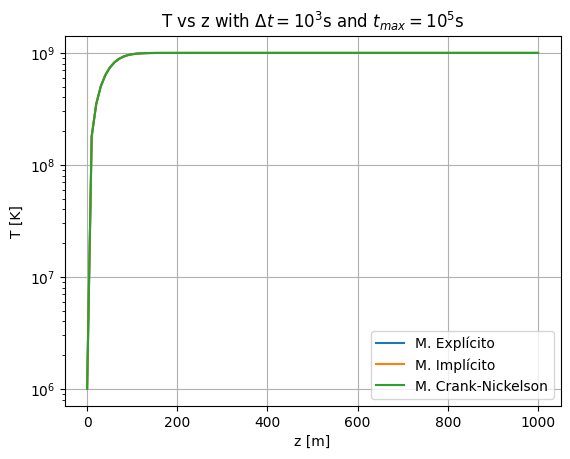

Stability number lambda =  0.09801000000000001


In [18]:
t = 0.
dt = 1000.0
t_max = 1.e5
n_steps = int(t_max / dt)
lam = alpha * dt / (dx**2)
# Inicializamos
T_exp = np.ones(N) * T_core
T_exp[0] = T_surf
T_exp[-1] = T_core

T_imp = np.ones(N) * T_core
T_imp[0] = T_surf
T_imp[-1] = T_core

T_cn = np.ones(N) * T_core
T_cn[0] = T_surf
T_cn[-1] = T_core

T_method = []

for paso in range(1, n_steps + 1):
    T_exp = explicit(T_exp.copy())
    T_imp = implicit(T_imp.copy())
    
    a, b, c, rhs = construir_sistema(T_cn.copy())
    T_cn = Thomas(a, b, c, rhs, N) # Para utilizar el Thomas que creamos
    
    t = t + dt 

    if t == t_max:
        print("Guardando snapshot de t=",t)
        T_method.append((T_exp.copy(), "M. Explícito"))
        T_method.append((T_imp.copy(), "M. Implícito"))
        T_method.append((T_cn.copy(), "M. Crank-Nickelson"))

for (T_snap, t_snap) in T_method:
    plt.plot(x, T_snap, label = f"{t_snap}")

plt.legend()
plt.grid()
plt.title(r"T vs z with $\Delta t = 10^3$s and $t_{max} = 10^5$s")
plt.xlabel("z [m]")
plt.ylabel("T [K]")
plt.yscale("log")
plt.show()


print("Stability number lambda = ", lam)

Vemos que, para este valor de $\Delta t$, en realidad no hay mucha diferencia entre los métodos.

## Para $\Delta t = 10^4$s

Guardando snapshot de t= 100000.0


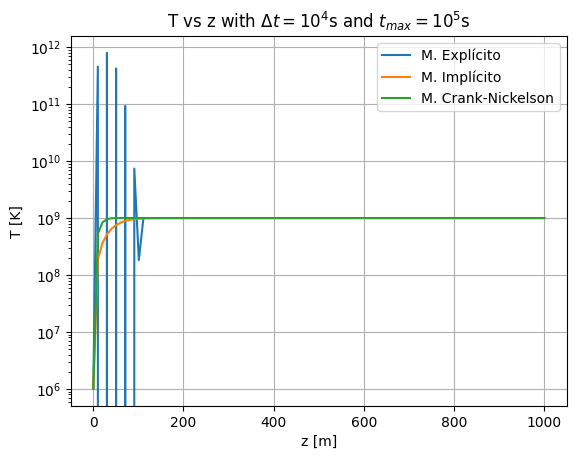

Stability number lambda =  0.9801000000000001


In [19]:
t = 0.
dt = 10000.0
t_max = 1.e5
n_steps = int(t_max / dt)
lam = alpha * dt / (dx**2)
# Inicializamos
T_exp = np.ones(N) * T_core
T_exp[0] = T_surf
T_exp[-1] = T_core

T_imp = np.ones(N) * T_core
T_imp[0] = T_surf
T_imp[-1] = T_core

T_cn = np.ones(N) * T_core
T_cn[0] = T_surf
T_cn[-1] = T_core

T_method = []

for paso in range(1, n_steps + 1):
    T_exp = explicit(T_exp)
    T_imp = implicit(T_imp)
    
    a, b, c, rhs = construir_sistema(T_cn)
    T_cn = Thomas(a, b, c, rhs, N) # Para utilizar el Thomas que creamos
    
    t = t + dt 

    if t == t_max:
        print("Guardando snapshot de t=",t)
        T_method.append((T_exp, "M. Explícito"))
        T_method.append((T_imp, "M. Implícito"))
        T_method.append((T_cn, "M. Crank-Nickelson"))

for (T_snap, t_snap) in T_method:
    plt.plot(x, T_snap, label = f"{t_snap}")

plt.legend()
plt.grid()
plt.title(r"T vs z with $\Delta t = 10^4$s and $t_{max} = 10^5$s")
plt.xlabel("z [m]")
plt.ylabel("T [K]")
plt.yscale("log")
plt.show()

print("Stability number lambda = ", lam)

### Conclusiones

Vemos que los tres métodos para $\Delta t = 10^3$s se comportan idénticamente (en apariencia, por lo menos). Esto se puede deber a que la condición de estabilidad se satisface $\lambda = 0.098 < 0.5$.

Por otra parte, para el $\Delta t = 10^4$s, perdemos esta condición con un $\lambda = 0.98 > 0.5$, por lo tanto, no podemos garantizar estabilidad numérica en nuestra solución, lo cual explota en el método explícito, al ser el más sencillo.